# Anxiety Test Model

Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

Load Data

In [2]:
df = pd.read_csv('enhanced_anxiety_dataset.csv')

Learn more about the Data

In [3]:
df

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0


In [4]:
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


In [5]:
print(f"The shape of the Data is {df.shape}")
df.describe()

The shape of the Data is (11000, 19)


,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10)
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,40.241727,6.650691,2.942136,286.090000,9.701636,5.856364,90.916000,20.957545,3.080636,2.427818,5.181818,3.929364
std,13.236140,1.227509,1.827825,144.813157,5.689713,2.927202,17.325721,5.160107,1.398877,2.183106,2.895243,2.122533
min,18.000000,2.300000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000
25%,29.000000,5.900000,1.500000,172.000000,5.000000,3.000000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000
50%,40.000000,6.700000,2.800000,273.000000,10.000000,6.000000,92.000000,21.000000,3.000000,2.000000,5.000000,4.000000
75%,51.000000,7.500000,4.200000,382.000000,15.000000,8.000000,106.000000,25.000000,4.000000,4.000000,8.000000,5.000000
max,64.000000,11.300000,10.100000,599.000000,19.000000,10.000000,119.000000,29.000000,5.000000,12.000000,10.000000,10.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

In [7]:
df.duplicated().sum()

np.int64(0)

Get to know the Target Values

Text(0.5, 1.0, 'Countplot of Anxiety')

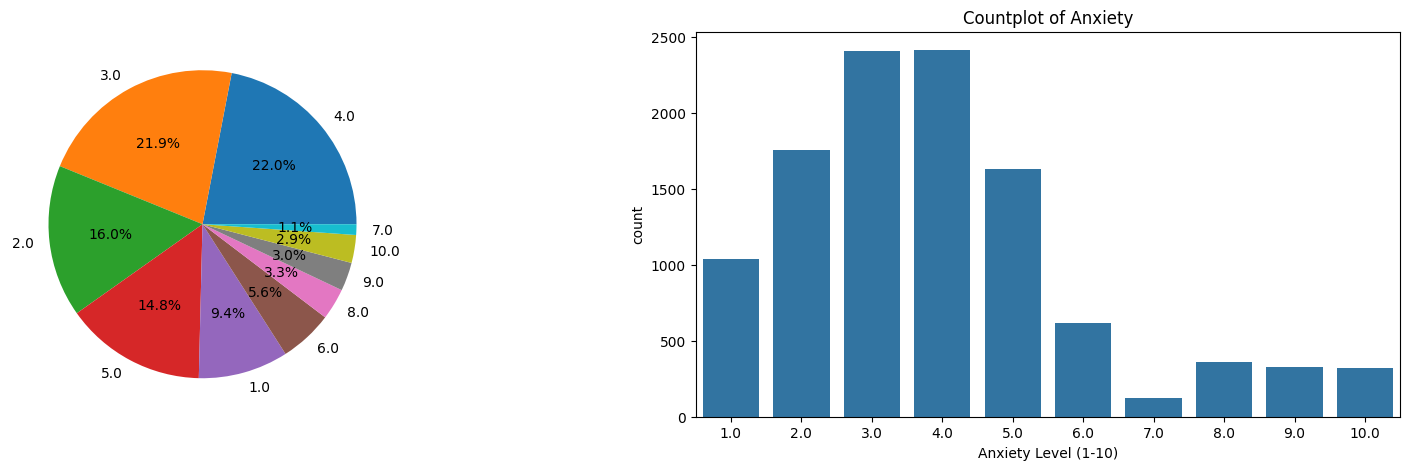

In [8]:
Anxiety_counts = df['Anxiety Level (1-10)'].value_counts()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

axes[0].pie(Anxiety_counts, labels=Anxiety_counts.index, autopct='%1.1f%%')
plt.title('Anxiety Distribution')

sns.countplot(x=df['Anxiety Level (1-10)'], ax=axes[1])
axes[1].set_title('Countplot of Anxiety')

In [9]:
# Reclassify target into 3 categories
def categorize_anxiety(level):
    if level <= 3:
        return 0  # Low
    elif level <= 7:
        return 1  # Moderate
    else:
        return 2  # High

df['Anxiety Level (1-10)'] = df['Anxiety Level (1-10)'].apply(categorize_anxiety)

In [10]:
# A function to draw the target values' percentage
def plot_pie(y2, title):
    plt.figure(figsize=(4, 4))
    pd.Series(y2).value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(title)
    plt.show()

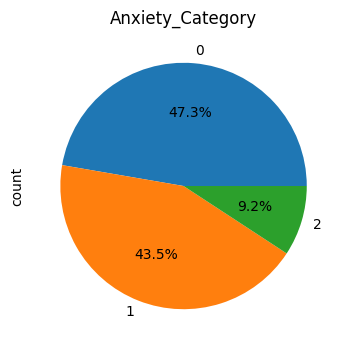

In [11]:
plot_pie(df['Anxiety Level (1-10)'], 'Anxiety_Category')

Prepare the Data

In [12]:
numeric_cols = ['Age', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)',
                'Alcohol Consumption (drinks/week)', 'Stress Level (1-10)', 'Heart Rate (bpm)',
                'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)']

binary_cols = ['Smoking', 'Family History of Anxiety', 'Dizziness', 'Medication','Recent Major Life Event']

cat_cols = ['Gender', 'Occupation']

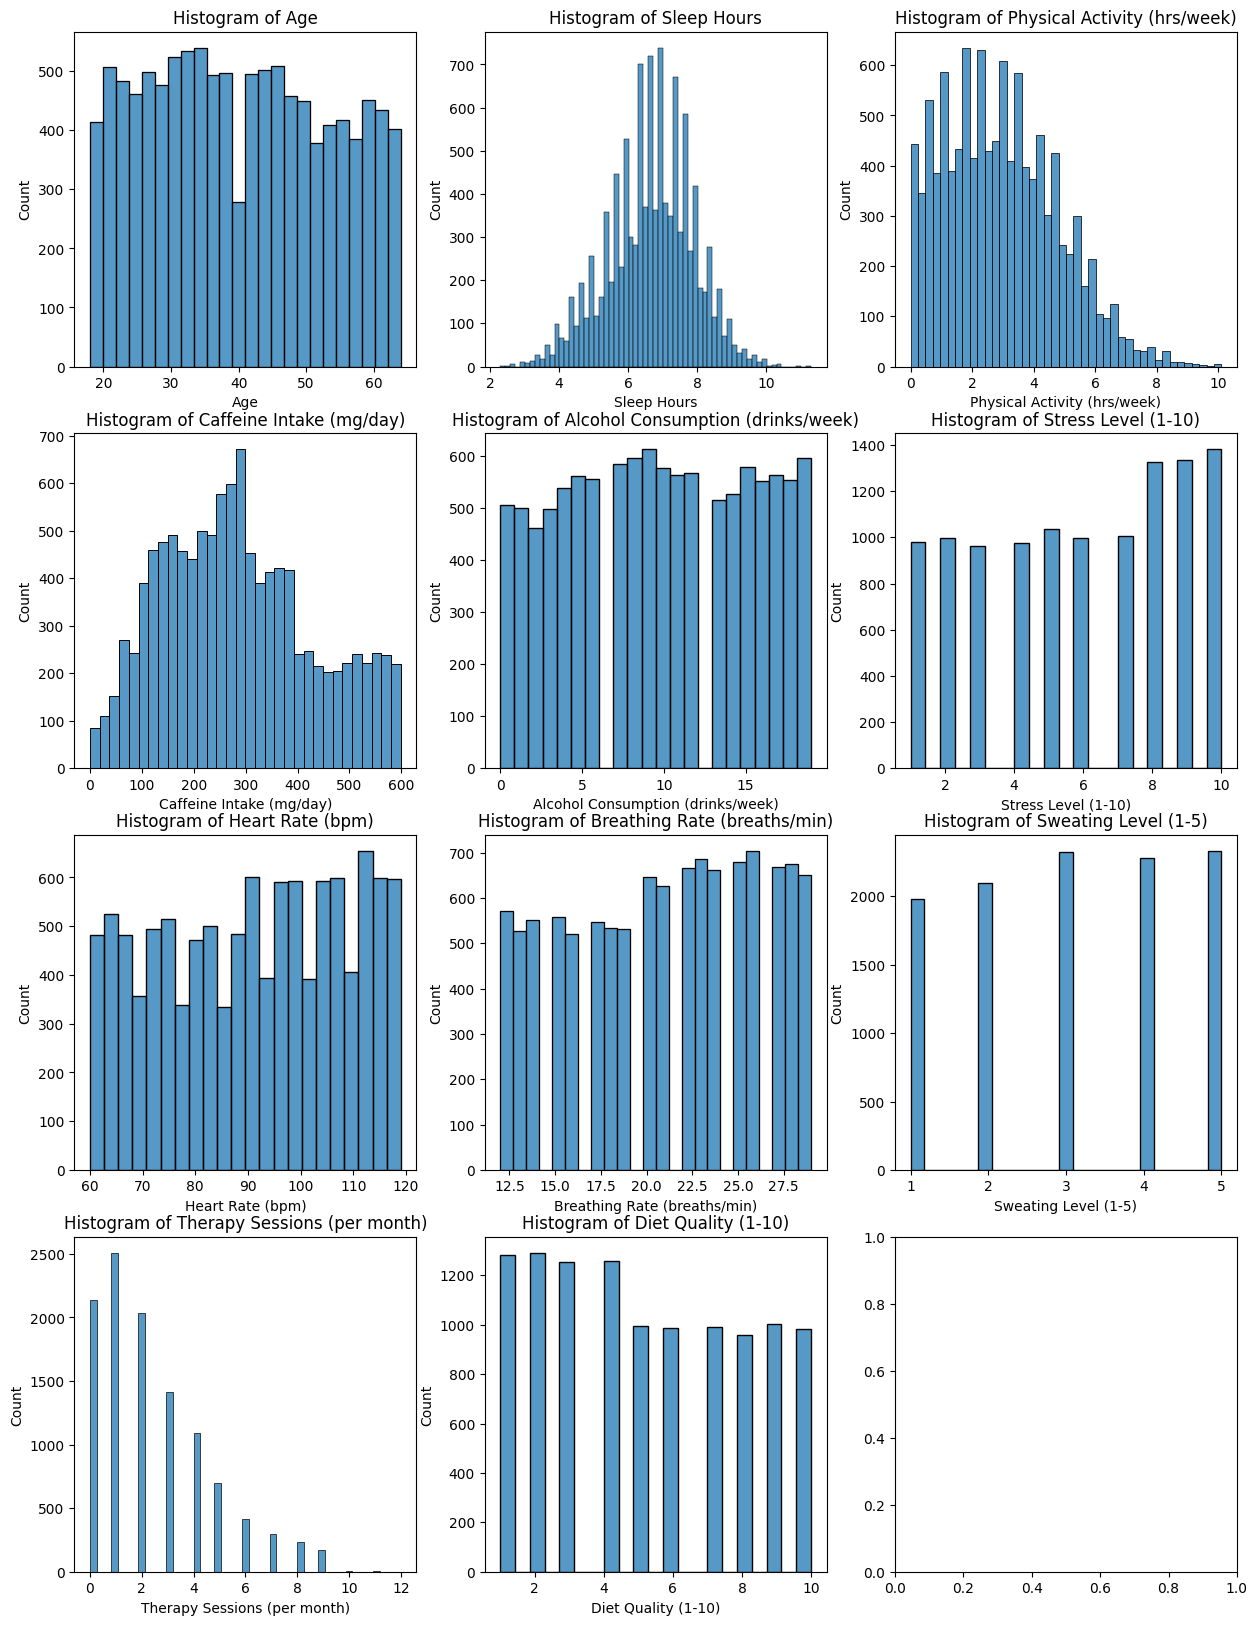

In [13]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))

for i, col in enumerate(numeric_cols):
  sns.histplot(df[col], ax=axes[i // 3, i % 3])
  axes[i // 3, i % 3].set_title(f'Histogram of {col}')

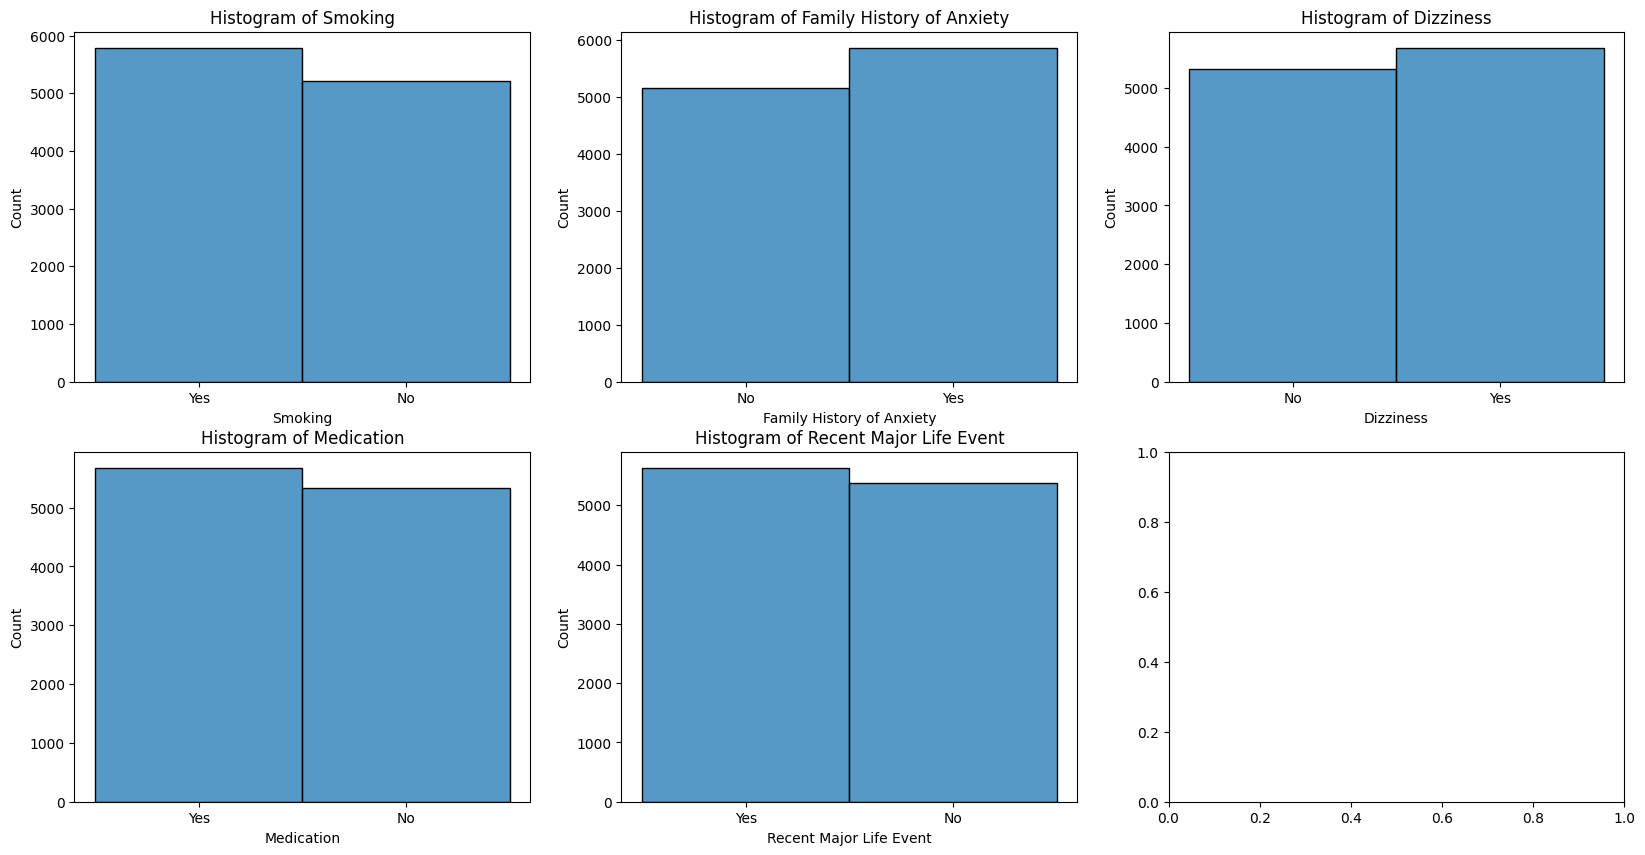

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

for i, col in enumerate(binary_cols):
  sns.histplot(df[col], ax=axes[i // 3, i % 3])
  axes[i // 3, i % 3].set_title(f'Histogram of {col}')

In [15]:
bibool = {'Yes': 1, 'No': 0}

for i, col in enumerate(binary_cols):
  df[col] = df[col].map(bibool)

In [16]:
df.head(10)

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,1,0,10,114,14,4,0,1,3,1,7,1
1,46,Other,Nurse,6.2,5.7,200,8,1,1,1,62,23,2,1,0,2,0,8,0
2,64,Male,Other,5.0,3.7,117,4,0,1,1,91,28,3,0,0,1,1,1,0
3,20,Female,Scientist,5.8,2.8,360,6,1,0,4,86,17,3,0,0,0,0,1,0
4,49,Female,Other,8.2,2.3,247,4,1,0,1,98,19,4,1,1,1,0,3,0
5,53,Male,Other,6.4,6.5,235,2,0,0,9,84,14,3,0,1,2,1,5,1
6,20,Male,Artist,7.9,2.5,78,14,1,0,8,118,21,5,1,0,1,1,2,1
7,54,Female,Lawyer,6.3,5.5,535,15,0,0,5,113,19,1,0,0,0,0,7,1
8,51,Other,Lawyer,6.6,3.1,587,2,0,0,2,81,22,1,1,0,2,1,8,0
9,59,Female,Teacher,5.1,4.8,159,15,1,0,5,95,28,5,1,1,1,1,1,1


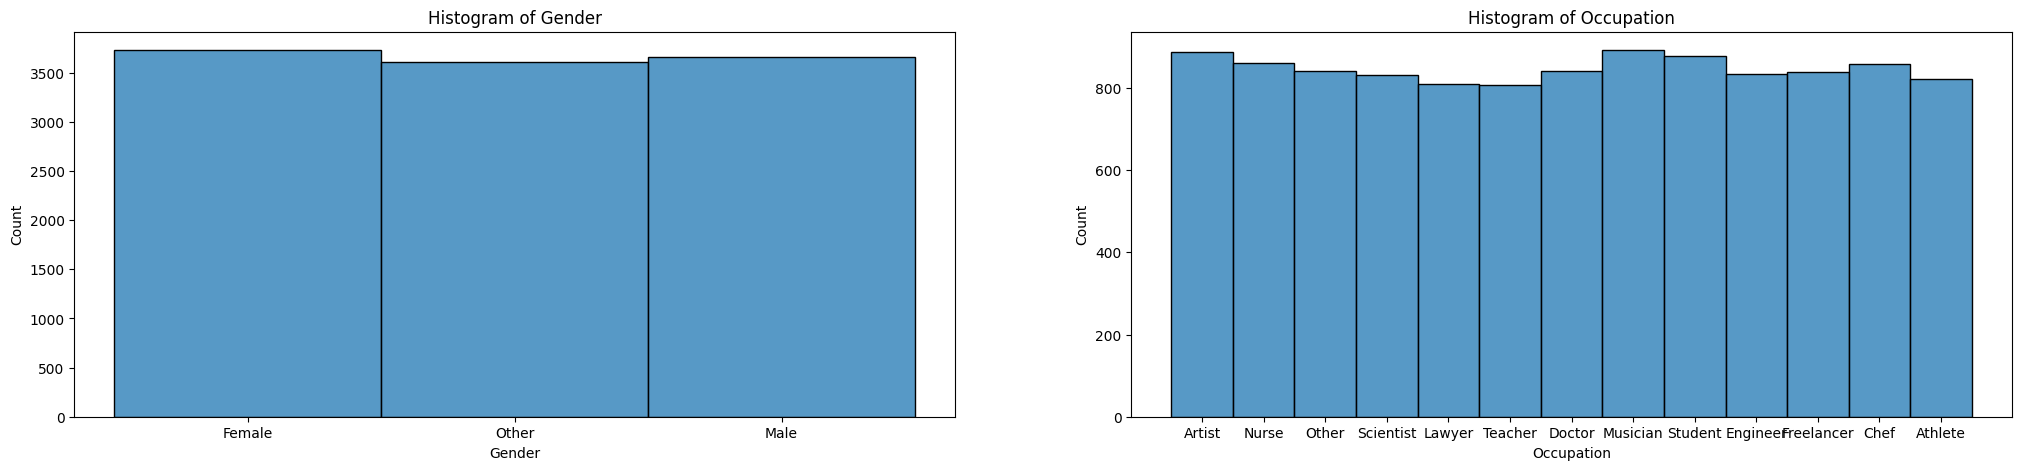

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 5))

for i, col in enumerate(cat_cols):
  sns.histplot(df[col], ax=axes[i])
  axes[i].set_title(f'Histogram of {col}')

In [18]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1, 'Other': -1})

In [19]:
print(df['Occupation'].unique())
print(len(df['Occupation'].unique()))

['Artist' 'Nurse' 'Other' 'Scientist' 'Lawyer' 'Teacher' 'Doctor'
 'Musician' 'Student' 'Engineer' 'Freelancer' 'Chef' 'Athlete']
13


Target Encode the 'Occupation' column

In [20]:
# Calculate the mean of the target variable ('Anxiety Level') for each category in 'Occupation'
occupation_target_mean = df.groupby('Occupation')['Anxiety Level (1-10)'].mean()

# Map the calculated mean to the 'Occupation' column
df['Occupation'] = df['Occupation'].map(occupation_target_mean)

df.head(10)

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,1,0.581081,6.0,2.7,181,10,1,0,10,114,14,4,0,1,3,1,7,1
1,46,-1,0.602787,6.2,5.7,200,8,1,1,1,62,23,2,1,0,2,0,8,0
2,64,0,0.557143,5.0,3.7,117,4,0,1,1,91,28,3,0,0,1,1,1,0
3,20,1,0.650240,5.8,2.8,360,6,1,0,4,86,17,3,0,0,0,0,1,0
4,49,1,0.557143,8.2,2.3,247,4,1,0,1,98,19,4,1,1,1,0,3,0
5,53,0,0.557143,6.4,6.5,235,2,0,0,9,84,14,3,0,1,2,1,5,1
6,20,0,0.581081,7.9,2.5,78,14,1,0,8,118,21,5,1,0,1,1,2,1
7,54,1,0.702101,6.3,5.5,535,15,0,0,5,113,19,1,0,0,0,0,7,1
8,51,-1,0.702101,6.6,3.1,587,2,0,0,2,81,22,1,1,0,2,1,8,0
9,59,1,0.572491,5.1,4.8,159,15,1,0,5,95,28,5,1,1,1,1,1,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  int64  
 2   Occupation                         11000 non-null  float64
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  int64  
 8   Family History of Anxiety          11000 non-null  int64  
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

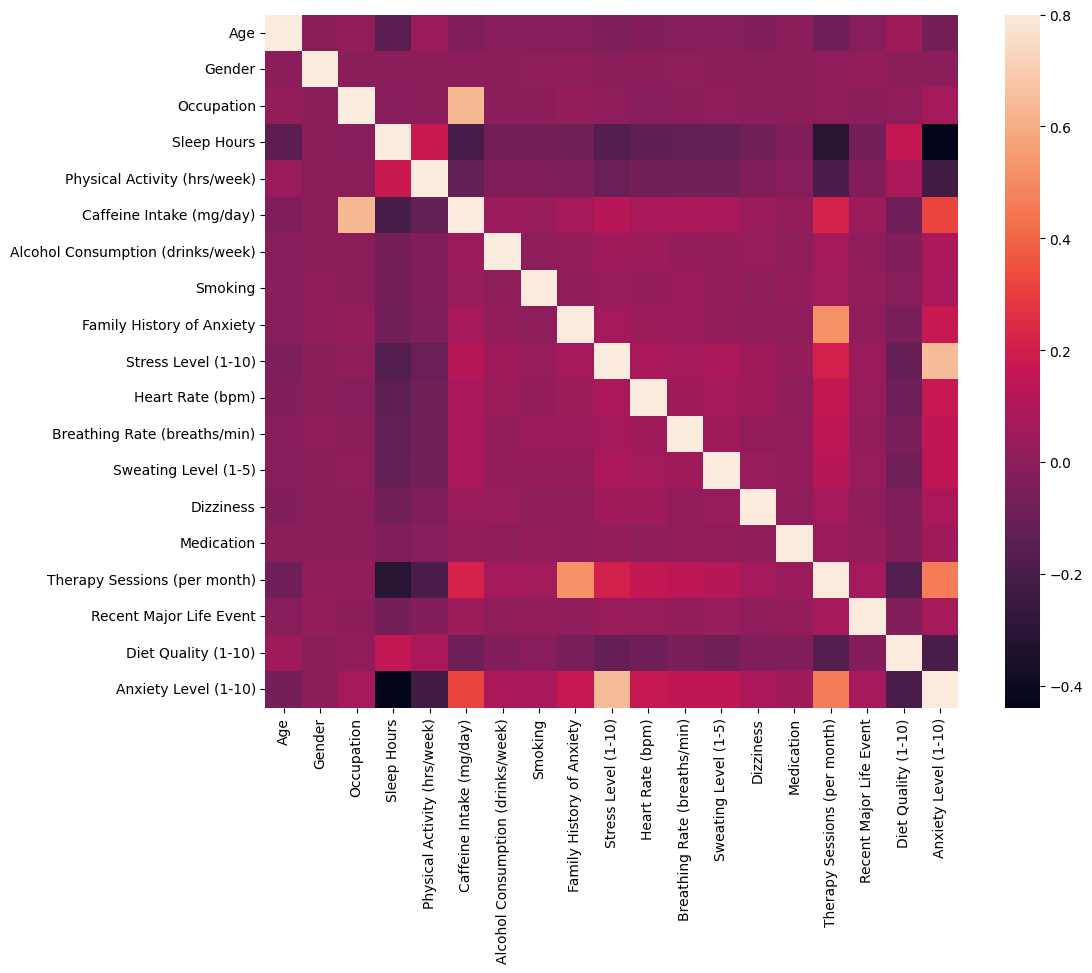

In [22]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

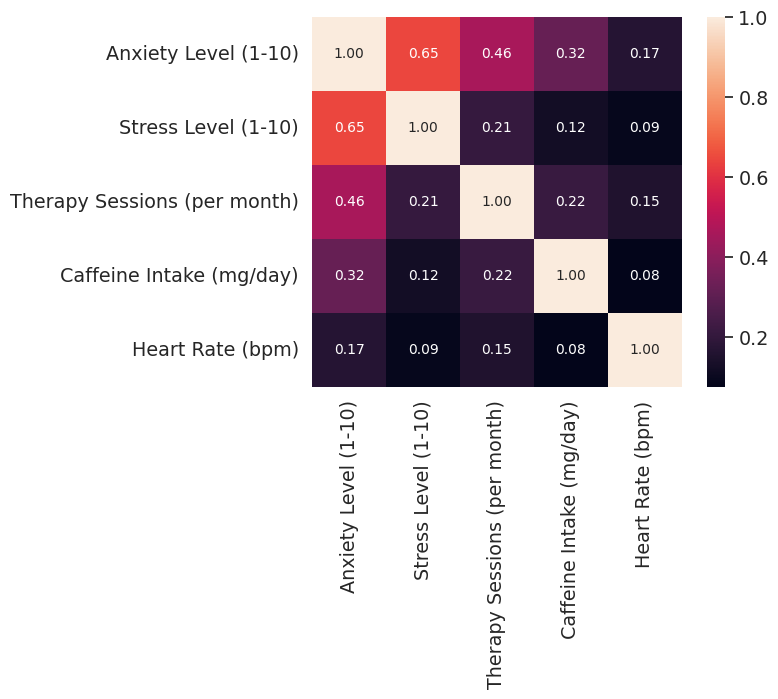

In [23]:
k = 5 #number of variables for heatmap
cols = corrmat.nlargest(k, 'Anxiety Level (1-10)')['Anxiety Level (1-10)'].index # nlargest pick the most powerfull 10 correlation
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [24]:
X = df.drop('Anxiety Level (1-10)', axis=1)
y = df['Anxiety Level (1-10)']

In [26]:
sd = StandardScaler(copy=True, with_mean=True, with_std=True)
X[numeric_cols] = sd.fit_transform(X[numeric_cols])

In [ ]:
x_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.3, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(X_, y_, test_size=0.67, random_state=1)

del X_, y_

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_val.shape}")
print(f"the shape of the cross validation set (target) is: {y_val.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (10924, 18)
the shape of the training set (target) is: (10924,)

the shape of the cross validation set (input) is: (1545, 18)
the shape of the cross validation set (target) is: (1545,)

the shape of the test set (input) is: (3137, 18)
the shape of the test set (target) is: (3137,)


Anxiety Level (1-10)
0    5202
1    4784
2    1014
Name: count, dtype: int64
Anxiety Level (1-10)
1    5202
0    5202
2    5202
Name: count, dtype: int64
Number of records added 4606


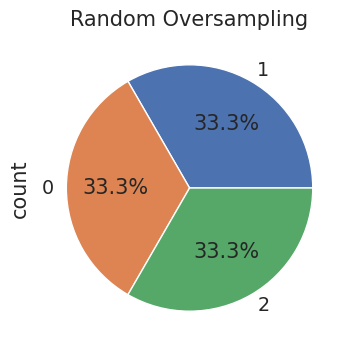

In [ ]:
#SMOTE_Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=1)
x_sos, y_sos = smote.fit_resample(x_train, y_train)

print(y.value_counts())
print(y_sos.value_counts())
print(f'Number of records added {y_sos.shape[0] - y.shape[0]}')
plot_pie(y_sos, 'Random Oversampling')

In [28]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout

num_classes = len(np.unique(y_train))

tf.random.set_seed(1234)
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(x_train.shape[1],), name = 'L1'),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001), name = 'L2'),
    Dropout(0.3),
    Dense(32, activation='relu', name = 'L3'),
    Dense(num_classes, activation='softmax', name = 'L4')
    ], name = "anxiety_model"
)


In [29]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    metrics=['accuracy']
)

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

In [31]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3349 - loss: 11.3707 - val_accuracy: 0.3405 - val_loss: 1.3125
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3742 - loss: 2.4660 - val_accuracy: 0.3663 - val_loss: 1.1572
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3751 - loss: 1.6297 - val_accuracy: 0.3586 - val_loss: 1.1396
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3798 - loss: 1.3718 - val_accuracy: 0.5301 - val_loss: 1.1231
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4099 - loss: 1.2424 - val_accuracy: 0.4984 - val_loss: 1.1112
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4150 - loss: 1.2064 - val_accuracy: 0.5424 - val_loss: 1.0928
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4296 - loss: 1.1667 - val_accuracy: 0.5515 - val_loss: 1.0809
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4595 - loss: 1.1262 - val_acc

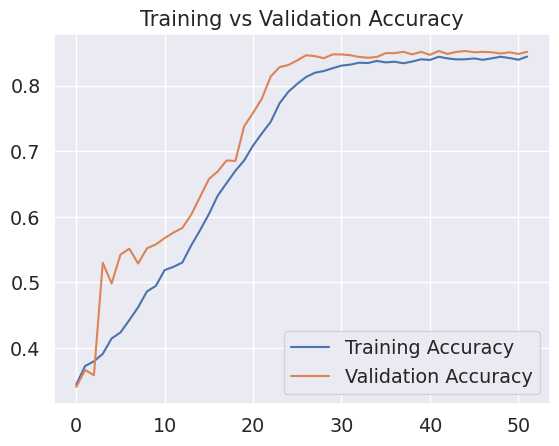

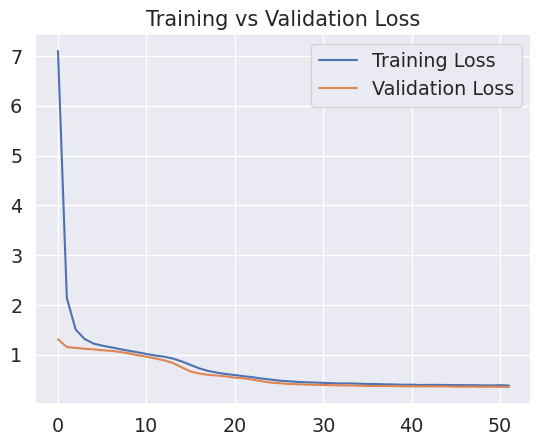

In [32]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [33]:
model.summary()

Model: "anxiety_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4 (Dense)                      │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,603 (150.80 KB)

 Trainable params: 12,867 (50.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,736 (100.54 KB)

In [34]:
pred = np.argmax(model.predict(x_test), axis=1)

print("Prediction Results")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Prediction Results
Accuracy: 0.8552757411539688
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      1060
           1       0.76      0.81      0.78      1014
           2       0.99      0.99      0.99      1063

    accuracy                           0.86      3137
   macro avg       0.86      0.85      0.85      3137
weighted avg       0.86      0.86      0.86      3137



In [35]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
gap = abs(train_acc - val_acc)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")
print(f"Generalization Gap: {gap:.3f}")

if gap > 0.1:
    print("The Model is overfitting.")
elif val_acc < 0.8:
    print("The Model may be underfitting (needs more complexity or data).")
else:
    print("The Model is well balanced.")

Train Accuracy: 0.845
Validation Accuracy: 0.852
Generalization Gap: 0.007
The Model is well balanced.


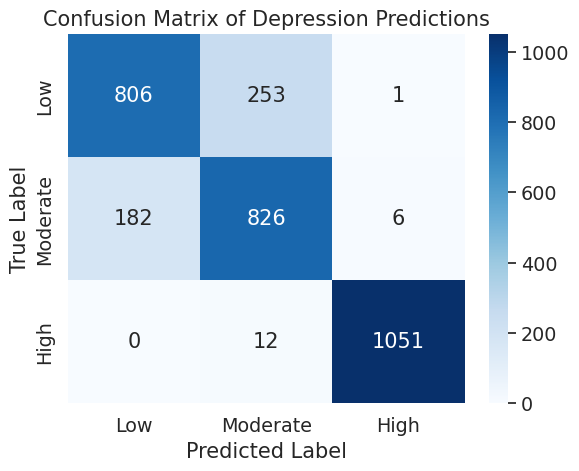

In [36]:
cm = confusion_matrix(y_test, pred)

labels = ['Low', 'Moderate', 'High']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Depression Predictions')
plt.show()

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


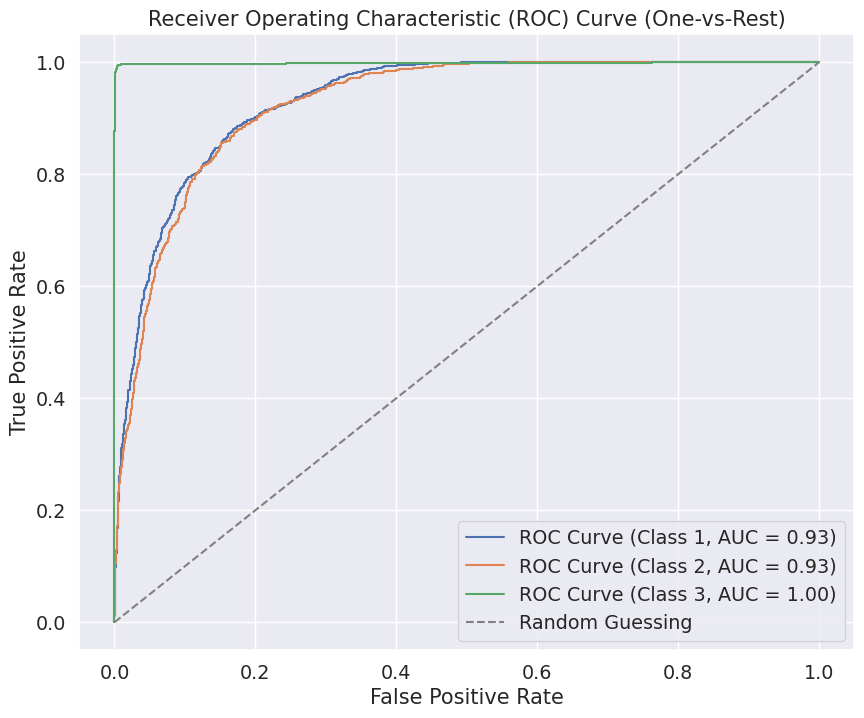

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from tensorflow.keras.activations import softmax

# Get the predicted probabilities by applying softmax to the model's output logits
pred_proba = softmax(model.predict(x_test)).numpy()

# Calculate ROC AUC and plot ROC curve for each class using One-vs-Rest (OvR)
plt.figure(figsize=(10, 8))

# Assuming y_test contains integer labels from 0 to 9
num_classes = len(np.unique(y_test))

for i in range(num_classes):
    # Binarize the true labels for the current class (OvR approach)
    y_true_binary = (y_test == i).astype(int)

    # Get the predicted probabilities for the current class
    y_pred_proba_class = pred_proba[:, i]

    # Calculate ROC curve points
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_pred_proba_class)

    # Calculate AUC for the current class
    auc = roc_auc_score(y_true_binary, y_pred_proba_class)

    # Plot the ROC curve for the current class
    plt.plot(fpr, tpr, label=f'ROC Curve (Class {i+1}, AUC = {auc:.2f})') # Display class label as 1-10

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (One-vs-Rest)')
plt.legend()
plt.grid(True)
plt.show()

# You can also calculate the average AUC across all classes if needed
# roc_auc_scores = []
# for i in range(num_classes):
#     y_true_binary = (y_test == i).astype(int)
#     y_pred_proba_class = pred_proba[:, i]
#     auc = roc_auc_score(y_true_binary, y_pred_proba_class)
#     roc_auc_scores.append(auc)
# print(f"\nAverage ROC AUC (OvR): {np.mean(roc_auc_scores):.2f}")

In [38]:
"""import joblib
joblib.dump(model, "anxiety_model.pkl")
from google.colab import files
files.download('anxiety_model.pkl')"""

'import joblib\njoblib.dump(model, "anxiety_model.pkl")\nfrom google.colab import files\nfiles.download(\'anxiety_model.pkl\')'